In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sklearn packages
from sklearn.preprocessing import (StandardScaler, 
                                    MinMaxScaler)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, train_test_split

from sklearn.metrics import (accuracy_score, 
                            classification_report, 
                            confusion_matrix, 
                            ConfusionMatrixDisplay)


# MNE Packages
import mne
from mne.datasets.sleep_physionet.age import fetch_data
mne.utils.set_config('MNE_USE_CUDA', 'true')

# Parametric T-SNE
import sys
sys.path.append("..") 
from parametric_tsne.parametric_tSNE import Parametric_tSNE


/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Step 1 : Load Numpy Dataset

In [2]:
TRAIN_FILE_PATH = "../data/mne/train.npz"
VALID_FILE_PATH = "../data/mne/valid.npz"
TEST_FILE_PATH = "../data/mne/test.npz"

In [ ]:
# Train
train = np.load(TRAIN_FILE_PATH)
X_train, y_train = train["arr_0"], train["arr_1"].astype(int)

# Valid
valid = np.load(VALID_FILE_PATH)
X_valid, y_valid = valid["arr_0"], valid["arr_1"].astype(int)

X, y = np.vstack([X_train, X_valid]), np.hstack([y_train, y_valid])

# Test
test = np.load(TEST_FILE_PATH)
X_test, y_test = test["arr_0"], test["arr_1"].astype(int)

print(f"Shape of X_train : {X_train.shape} and y_train : {y_train.shape}")
print(f"Shape of X_val : {X_valid.shape} and y_valid : {y_valid.shape}")
print(f"Shape of X_test : {X_test.shape} and y_test : {y_test.shape}")

Shape of X_train : (20776, 320) and y_train : (20776,)
Shape of X_val : (3596, 320) and y_valid : (3596,)
Shape of X_test : (3686, 320) and y_test : (3686,)


In [7]:
X = X[(y != 0)]
X_test = X_test[(y_test != 0)]

In [8]:
y = y[(y != 0)]
y_test = y_test[(y_test != 0)]

## Step -2: Build Parametric T-SNE Model

In [9]:
class BuildParametricTsneModel:

    def __init__(self, num_outputs: int, 
                        perplexity: int, 
                        scaling:bool, 
                        input_arr : np.ndarray, 
                        epochs : int):
        """ 
            Function : Build Parametric T-SNE Model 
            Arguments:
                num_outputs : int : lower dimension 
        """
        self.num_outputs = num_outputs
        self.perplexity = perplexity
        self.scaling = scaling
        self.epochs = epochs # Number of iterations
        self.input_arr = input_arr # Higher Dimensional Array

    @staticmethod
    def MinMaxScaling(input_arr:np.ndarray):
        sc = MinMaxScaler()
        sc.fit(input_arr)

        return sc

    def train(self):
        X_copy = self.input_arr.copy() # Copy 

        # Scaling
        if self.scaling == True:
            self.sc = BuildParametricTsneModel.MinMaxScaling(input_arr = X_copy)
            X_copy = self.sc.transform(X_copy)

        # Fit the Model
        self.ptSNE = Parametric_tSNE(X_copy.shape[1], 
                                    self.num_outputs, 
                                    self.perplexity)
        self.ptSNE.fit(X_copy, epochs = self.epochs)

    def fit(self, X: np.ndarray):
        # Scaling during Transform stage
        if self.scaling == True:
            X = self.sc.transform(X)

        X = self.ptSNE.transform(X)
        return X
        

ptsne_model = BuildParametricTsneModel(
    num_outputs= 10, 
    perplexity = 30, 
    scaling = True,
    input_arr = X, 
    epochs= 5
)

# Fit the Model
ptsne_model.train()

/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Train and Test 
X_Ptrain = ptsne_model.fit(X)
X_Ptest = ptsne_model.fit(X_test)

394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


## Step -3 SVM Model

In [11]:
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, train_test_split
from sklearn.svm import SVC

# --- Parameter ranges (smaller but effective) --- #
C_range = np.logspace(-2, 4, 7)
gamma_range = np.logspace(-6, 1, 7)
param_grid = dict(C=C_range, gamma=gamma_range)

# --- Cross-validation setup --- #
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# --- Use a subset for faster tuning --- #
X_sub, _, y_sub, _ = train_test_split(
    X_Ptrain, y, train_size=5000, stratify=y, random_state=42
)

# --- Randomized Search with parallelization --- #
grid = RandomizedSearchCV(
    SVC(kernel='rbf'),
    param_distributions=param_grid,
    n_iter=20,            # sample only 20 parameter combinations
    cv=cv,
    n_jobs=-1,            # use all CPU cores
    random_state=42,
    verbose=1
)

# --- Fit on the subset --- #
grid.fit(X_sub, y_sub)

print("Best parameters:", grid.best_params_)
print("Best CV score: %.2f" % grid.best_score_)

# --- Retrain final model on full data --- #
best_model = SVC(kernel='rbf', **grid.best_params_)
best_model.fit(X_Ptrain, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'gamma': np.float64(0.00021544346900318845), 'C': np.float64(10000.0)}
Best CV score: 0.31


SVC(C=np.float64(10000.0), gamma=np.float64(0.00021544346900318845))

# Train Predictions

              precision    recall  f1-score   support

           1       0.30      0.57      0.40      3223
           2       0.32      0.31      0.31      3231
           3       0.44      0.24      0.31      3105
           4       0.32      0.19      0.24      3046

    accuracy                           0.33     12605
   macro avg       0.35      0.33      0.32     12605
weighted avg       0.35      0.33      0.32     12605



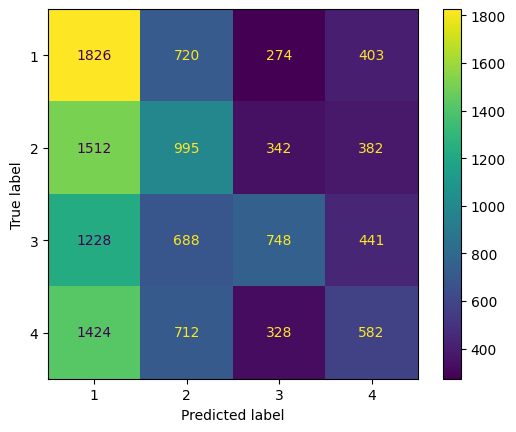

In [12]:
# Model Fitting and Predictions
y_pred_train = best_model.predict(X_Ptrain)

# Confusion Matrix
cm = confusion_matrix(y, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y, y_pred_train, ))

# Test Predictions

              precision    recall  f1-score   support

           1       0.31      0.59      0.41       503
           2       0.34      0.29      0.31       499
           3       0.42      0.23      0.30       452
           4       0.29      0.19      0.23       452

    accuracy                           0.33      1906
   macro avg       0.34      0.32      0.31      1906
weighted avg       0.34      0.33      0.31      1906



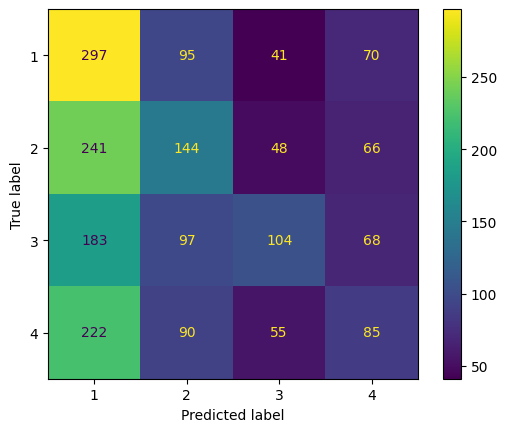

In [13]:
# Model Fitting and Predictions
y_pred = best_model.predict(X_Ptest)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_test, y_pred, ))

## Step 4 : Random Forest Model

In [14]:
def tune_random_forest_full(X, y, n_iter=20, random_state=42):
    """
    Tune RandomForestClassifier using RandomizedSearchCV on the full dataset
    and return the best model trained on all data.

    Parameters:
    -----------
    X : array-like
        Feature matrix.
    y : array-like
        Target labels.
    n_iter : int, optional
        Number of random parameter combinations to try. Default = 20
    random_state : int, optional
        Seed for reproducibility. Default = 42

    Returns:
    --------
    best_model : RandomForestClassifier
        Random Forest model trained on the full dataset with best hyperparameters.
    """

    # --- Base Random Forest --- #
    rf = RandomForestClassifier(random_state=random_state)

    # --- Parameter space --- #
    param_distributions = {
        'n_estimators': [100],#, 200, 300, 500],
        'max_depth': [None, 10, 20, 30, 40],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None],
    }

    # --- Randomized Search with 5-fold CV --- #
    rf_random = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=5,                   # cross-validation folds
        verbose=2,
        random_state=random_state,
        n_jobs=-1
    )

    # --- Fit search on full dataset --- #
    rf_random.fit(X, y)

    # --- Return the best model trained on all data --- #
    best_model = rf_random.best_estimator_
    print(rf_random.best_estimator_)
    best_model.fit(X, y)  # retrain on full dataset
    return best_model

best_rf = tune_random_forest_full(X_Ptrain, y, n_iter=2)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   3.0s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   3.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   3.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   3.1s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   3.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   3.2s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   3.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators

#### Step 4.1 Train Predictions

              precision    recall  f1-score   support

           1       0.96      0.99      0.97      3223
           2       0.99      0.98      0.98      3231
           3       0.98      0.97      0.98      3105
           4       0.99      0.98      0.98      3046

    accuracy                           0.98     12605
   macro avg       0.98      0.98      0.98     12605
weighted avg       0.98      0.98      0.98     12605



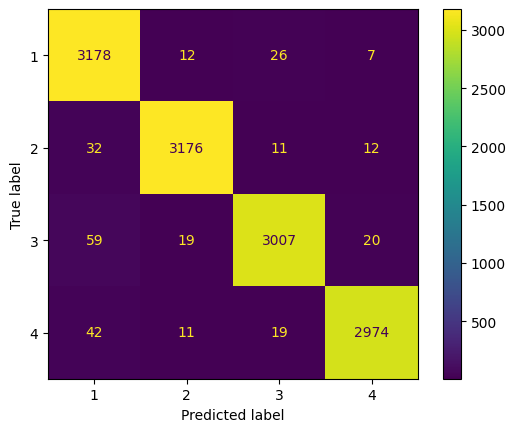

In [15]:
y_train_pred = best_rf.predict(X_Ptrain)
# Confusion Matrix
cm = confusion_matrix(y, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y, y_train_pred, ))

#### Step 4.2 Test Predictions

              precision    recall  f1-score   support

           1       0.68      0.74      0.71       503
           2       0.70      0.72      0.71       499
           3       0.71      0.68      0.69       452
           4       0.72      0.66      0.69       452

    accuracy                           0.70      1906
   macro avg       0.70      0.70      0.70      1906
weighted avg       0.70      0.70      0.70      1906



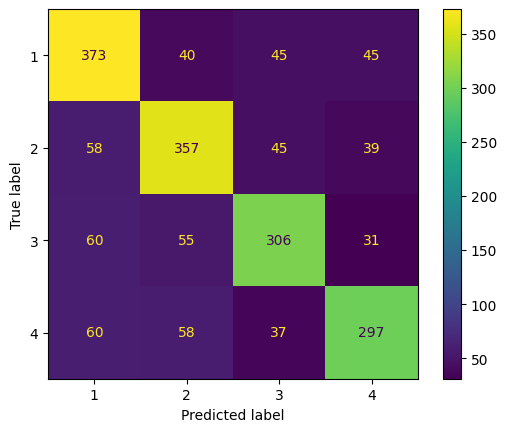

In [16]:
y_pred = best_rf.predict(X_Ptest)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_test, y_pred, ))